# Measuring Cosmological Parameters Using Type Ia Supernovae

In this project, we'll analyze observational data from the Pantheon+SH0ES dataset of Type Ia supernovae to measure the Hubble constant $H_0$ and estimate the age of the universe. 

Steps:
- Plot the Hubble diagram (distance modulus vs. redshift)
- Fit a cosmological model to derive $H_0$ and $\Omega_m$
- Estimate the age of the universe
- Analyze residuals to assess the model
- Explore the effect of fixing $\Omega_m$
- Compare low-z and high-z results



## Import Libraries

Before we dive into the analysis, we need to import the necessary Python libraries:

- `numpy`, `pandas` — for numerical operations and data handling
- `matplotlib` — for plotting graphs
- `scipy.optimize.curve_fit` and `scipy.integrate.quad` — for fitting cosmological models and integrating equations
- `astropy.constants` and `astropy.units` — for physical constants and unit conversions



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.constants import c
from astropy import units as u

from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

In [2]:
# Define a color palette - optional
colors = {
    'dark_purple': '#4B0082',
    'medium_purple': '#9370DB', 
    'light_purple': '#D4C1FF',
    'pink': '#FF69B4',
    'deep_pink': '#C71585',
    'rose': '#F06292',
    'light_pink': '#F48FB1',
    'aqua': '#B2EBF2',
    'baby_blue': '#A5D8FF'
}

# Custom colormap
cmap_custom = LinearSegmentedColormap.from_list(
    "cosmic_pink",
    [colors['deep_pink'], colors['pink'], colors['light_purple'], 
     colors['baby_blue'], colors['aqua']]
)

plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

## Load the Pantheon+SH0ES Dataset

We now load the observational supernova data from the Pantheon+SH0ES sample. This dataset includes calibrated distance moduli $\mu$, redshifts corrected for various effects, and uncertainties.

### About Dataset:
- The file is downloaded from [Pantheon dataset](https://github.com/PantheonPlusSH0ES/DataRelease/blob/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat).
- We use `delim_whitespace=True` because the file is space-delimited rather than comma-separated.
- Commented rows (starting with `#`) are automatically skipped.

We will extract:
- `zHD`: Hubble diagram redshift
- `MU_SH0ES`: Distance modulus using SH0ES calibration
- `MU_SH0ES_ERR_DIAG`: Associated uncertainty in Distance modulus


More detailed column names are given below:

`CID` - Name/ID of the Supernova (SN)
`CIDint` - Internal counter/index of the SN in the sample
`IDSURVEY` - ID number of the survey from which the SN was observed
`TYPE` - Type of SN (e.g., Type Ia); all in this sample are SNe Ia
`FIELD` - The survey field/region where the SN was observed
`CUTFLAG_SNANA` - Flag indicating cuts/failures in light-curve data (by SNANA)
`ERRFLAG_FIT` - Flag indicating errors in the light-curve fitting process
`zHEL` - Heliocentric redshift (i.e., measured with respect to the Sun)
`zHELERR` - Error in the heliocentric redshift
`zCMB` - Redshift corrected to the CMB (Cosmic Microwave Background) frame
`zCMBERR` - Error in zCMB
`zHD` - Hubble Diagram redshift (used in distance-redshift plots)
`zHDERR` - Error in Hubble Diagram redshift
`VPEC` - Peculiar velocity (velocity of the SN relative to cosmic expansion)
`VPECERR` - Error in the peculiar velocity
`MWEBV` - Milky Way dust extinction along the line of sight to the SN
`HOST_LOGMASS` - Logarithmic stellar mass of the SN’s host galaxy
`HOST_LOGMASS_ERR` - Error in host galaxy mass
`HOST_sSFR` - Specific star formation rate (sSFR) of the host galaxy
`HOST_sSFR_ERR` - Error in the sSFR
`PKMJDJINI` - Initial guess for the time of peak brightness (MJD format)
`SNRMAX1` - First highest signal-to-noise ratio in light curve
`SNRMAX2` - Second highest signal-to-noise ratio in light curve
`SNRMAX3` - Third highest signal-to-noise ratio in light curve
`PKMJD` - Fitted Modified Julian Date of SN peak brightness
`PKMJDERR` - Error in the fitted peak brightness date (PKMJD)

In [3]:
file_path = "Pantheon+SH0ES.dat"

# Load the csv file
df = pd.read_csv(file_path, delim_whitespace=True, comment='#')

C:\Users\cheri\AppData\Local\Temp\ipykernel_35892\1318805548.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, comment='#')


## Preview Dataset and its Columns

Before diving into the analysis, let’s take a quick look at the structure and column names of the dataset. This helps us verify the data loaded correctly and identify the relevant columns we’ll use for cosmological modeling.

In [4]:
print("Shape of dataset:")
print(df.shape)

Shape of dataset:
(1701, 47)


In [ ]:
print("Dataset info:")
print(df.info())

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1701 entries, 0 to 1700
Data columns (total 47 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CID                   1701 non-null   object 
 1   IDSURVEY              1701 non-null   int64  
 2   zHD                   1701 non-null   float64
 3   zHDERR                1701 non-null   float64
 4   zCMB                  1701 non-null   float64
 5   zCMBERR               1701 non-null   float64
 6   zHEL                  1701 non-null   float64
 7   zHELERR               1701 non-null   float64
 8   m_b_corr              1701 non-null   float64
 9   m_b_corr_err_DIAG     1701 non-null   float64
 10  MU_SH0ES              1701 non-null   float64
 11  MU_SH0ES_ERR_DIAG     1701 non-null   float64
 12  CEPH_DIST             1701 non-null   float64
 13  IS_CALIBRATOR         1701 non-null   int64  
 14  USED_IN_SH0ES_HF      1701 non-null   int64  
 15  c      

In [ ]:
print("Preview of dataset:")
print(df.head())

Preview of dataset:
             CID  IDSURVEY      zHD   zHDERR     zCMB  zCMBERR     zHEL  \
0         2011fe        51  0.00122  0.00084  0.00122  0.00002  0.00082   
1         2011fe        56  0.00122  0.00084  0.00122  0.00002  0.00082   
2         2012cg        51  0.00256  0.00084  0.00256  0.00002  0.00144   
3         2012cg        56  0.00256  0.00084  0.00256  0.00002  0.00144   
4  1994DRichmond        50  0.00299  0.00084  0.00299  0.00004  0.00187   

   zHELERR  m_b_corr  m_b_corr_err_DIAG  ...  PKMJDERR  NDOF   FITCHI2  \
0  0.00002   9.74571           1.516210  ...    0.1071    36   26.8859   
1  0.00002   9.80286           1.517230  ...    0.0579   101   88.3064   
2  0.00002  11.47030           0.781906  ...    0.0278   165  233.5000   
3  0.00002  11.49190           0.798612  ...    0.0667    55  100.1220   
4  0.00004  11.52270           0.880798  ...    0.0522   146  109.8390   

    FITPROB  m_b_corr_err_RAW  m_b_corr_err_VPEC  biasCor_m_b  biasCorErr_m_b  \
0  

In [7]:
print("Columns in dataset:")
print(df.columns.tolist())

Columns in dataset:
['CID', 'IDSURVEY', 'zHD', 'zHDERR', 'zCMB', 'zCMBERR', 'zHEL', 'zHELERR', 'm_b_corr', 'm_b_corr_err_DIAG', 'MU_SH0ES', 'MU_SH0ES_ERR_DIAG', 'CEPH_DIST', 'IS_CALIBRATOR', 'USED_IN_SH0ES_HF', 'c', 'cERR', 'x1', 'x1ERR', 'mB', 'mBERR', 'x0', 'x0ERR', 'COV_x1_c', 'COV_x1_x0', 'COV_c_x0', 'RA', 'DEC', 'HOST_RA', 'HOST_DEC', 'HOST_ANGSEP', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_LOGMASS', 'HOST_LOGMASS_ERR', 'PKMJD', 'PKMJDERR', 'NDOF', 'FITCHI2', 'FITPROB', 'm_b_corr_err_RAW', 'm_b_corr_err_VPEC', 'biasCor_m_b', 'biasCorErr_m_b', 'biasCor_m_b_COVSCALE', 'biasCor_m_b_COVADD']


## Clean and Extract Relevant Data

To ensure reliable fitting, we remove any rows that have missing values in key columns:

- `zHD`: redshift for the Hubble diagram  
- `MU_SH0ES`: distance modulus  
- `MU_SH0ES_ERR_DIAG`: uncertainty in the distance modulus  

We then extract these cleaned columns as NumPy arrays to prepare for analysis and modeling.


In [8]:
print("Checking for missing values:")
print(df.isnull().sum())

Checking for missing values:
CID                     0
IDSURVEY                0
zHD                     0
zHDERR                  0
zCMB                    0
zCMBERR                 0
zHEL                    0
zHELERR                 0
m_b_corr                0
m_b_corr_err_DIAG       0
MU_SH0ES                0
MU_SH0ES_ERR_DIAG       0
CEPH_DIST               0
IS_CALIBRATOR           0
USED_IN_SH0ES_HF        0
c                       0
cERR                    0
x1                      0
x1ERR                   0
mB                      0
mBERR                   0
x0                      0
x0ERR                   0
COV_x1_c                0
COV_x1_x0               0
COV_c_x0                0
RA                      0
DEC                     0
HOST_RA                 0
HOST_DEC                0
HOST_ANGSEP             0
VPEC                    0
VPECERR                 0
MWEBV                   0
HOST_LOGMASS            0
HOST_LOGMASS_ERR        0
PKMJD                   0
PKMJDERR 

In [ ]:
print("Checking for duplicated:")
print(df.duplicated().sum())

Checking for duplicated:
0


The dataset does not have any null values and does not contain any duplicates. So we can proceed with extracting of the necessary columns.

### Extract Relevant Columns

- `Redshift` is the increase in the wavelength of light from distant objects due to the expansion of the universe.
- `Distance modulus` is the difference between an object's apparent magnitude (how bright it appears from Earth) and absolute magnitude (how bright it would appear at a standard distance of 10 parsecs), used to calculate its distance.

In [10]:
z = df['zHD'].values
mu = df['MU_SH0ES'].values
mu_err = df['MU_SH0ES_ERR_DIAG'].values


### **Redshift Distribution across Cosmic Phases**

This histogram displays the distribution of redshift values (z) across three key cosmological eras based. It shows where most of the supernovae fall within these phases, providing insight into the observational coverage.

- **Local Universe (z < 0.1)** – Represents nearby galaxies in the relatively recent universe.
- **Intermediate Redshift (z ≈ 0.1 to 1.0)** – Captures a transitional phase where dark energy starts influencing cosmic expansion.
- **High Redshift (z > 1.0)** – Corresponds to earlier cosmic times when matter dominated the dynamics of the universe.


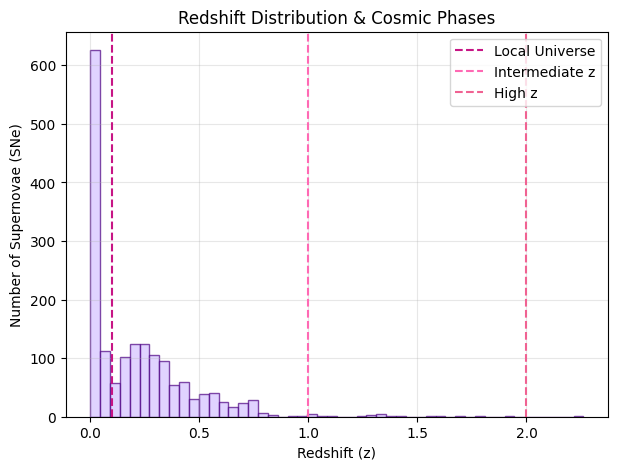

In [11]:
plt.figure(figsize=(7, 5))
plt.hist(z, bins=50, color=colors['light_purple'], alpha=0.7, edgecolor=colors['dark_purple'])
plt.axvline(0.1, color=colors['deep_pink'], linestyle='--', label='Local Universe')
plt.axvline(1.0, color=colors['pink'], linestyle='--', label='Intermediate z')
plt.axvline(2.0, color=colors['rose'], linestyle='--', label='High z')
plt.xlabel('Redshift (z)')
plt.ylabel('Number of Supernovae (SNe)')
plt.title('Redshift Distribution & Cosmic Phases')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Most of the supernovae were observed in the **local universe (z < 0.1)** because they are **brighter and easier to detect** with current telescopes.

## Plot the Hubble Diagram

The relationship between redshift $z$ and distance modulus $\mu$ is known as the Hubble diagram. This plot is a cornerstone of observational cosmology — it allows us to compare supernova observations with theoretical predictions based on different cosmological models.

We use a logarithmic scale on the redshift axis to clearly display both nearby and distant supernovae.

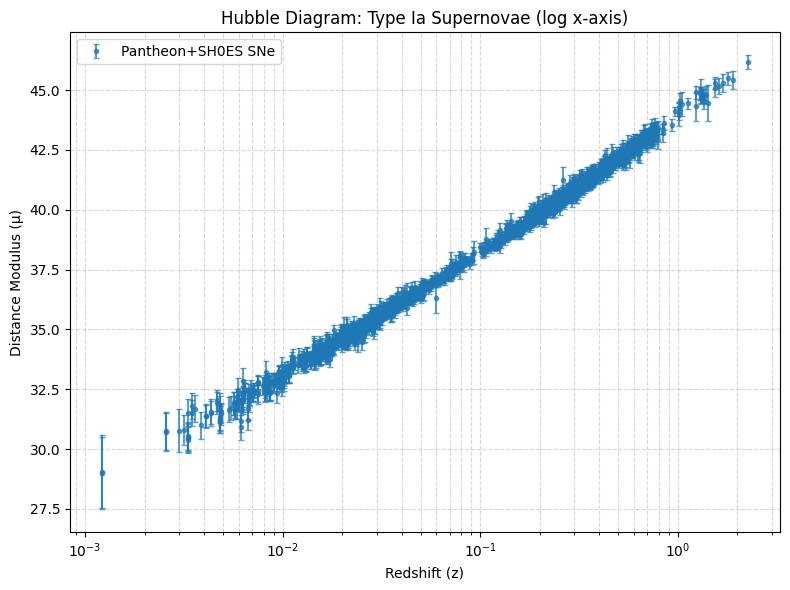

In [12]:
plt.figure(figsize=(8,6))
plt.errorbar(z, mu, yerr=mu_err, fmt='o', markersize=3, capsize=2, alpha=0.7, label='Pantheon+SH0ES SNe')
plt.xscale('log')
plt.xlabel('Redshift (z)')
plt.ylabel('Distance Modulus (μ)')
plt.title('Hubble Diagram: Type Ia Supernovae (log x-axis)')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


#### Hubble Diagram without log scaling

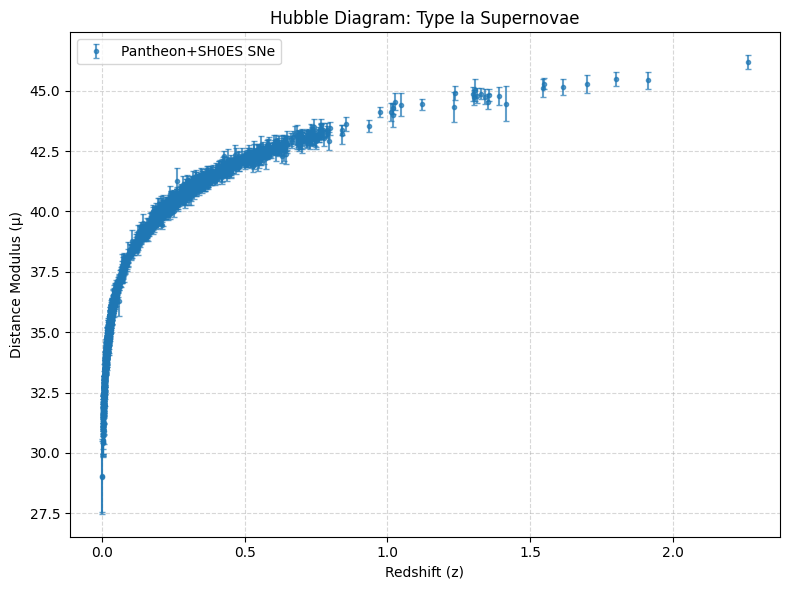

In [13]:
plt.figure(figsize=(8,6))
plt.errorbar(z, mu, yerr=mu_err, fmt='o', markersize=3, capsize=2, alpha=0.7, label='Pantheon+SH0ES SNe')
plt.xlabel('Redshift (z)')
plt.ylabel('Distance Modulus (μ)')
plt.title('Hubble Diagram: Type Ia Supernovae')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


## Define the Cosmological Model

We now define the theoretical framework based on the flat $\Lambda\mathrm{CDM}$ model. This involves:

- The dimensionless Hubble parameter:
  $$
  E(z) = \sqrt{\Omega_m (1+z)^3 + (1 - \Omega_m)}
  $$

- The luminosity distance :
  
  $$
  d_L(z) = (1 + z) \cdot \frac{c}{H_0} \int_0^z \frac{dz'}{E(z')}
  $$

- The distance modulus:
  $$
  \mu(z) = 5 \log_{10}(d_L [\text{Mpc}]) + 25
  $$

These equations allow us to compute the expected distance modulus from a given redshift $z$, Hubble constant $H_0$, and matter density parameter $\Omega_m$.


In [14]:
# Dimensionless Hubble Function - E(z) for flat LCDM
def E(z, Omega_m):
    return np.sqrt(Omega_m * (1 + z)**3 + (1 - Omega_m))


# Luminosity distance in Mpc
def luminosity_distance(z, H0, Omega_m):
    # Convert H0 from km/s/Mpc to 1/s
    H0_si = H0 * (u.km / u.s / u.Mpc)
    c_si = c.to('km/s').value  # c in km/s

    # Integrate 1/E(z)
    integral, _ = quad(lambda z_prime: 1.0 / E(z_prime, Omega_m), 0, z)

    dL = (1 + z) * c_si / H0 * integral  # in Mpc
    return dL


# Theoretical distance modulus
def mu_theory(z, H0, Omega_m):
    if isinstance(z, np.ndarray):
        return np.array([5 * np.log10(luminosity_distance(zi, H0, Omega_m)) + 25 for zi in z])
    else:
        return 5 * np.log10(luminosity_distance(z, H0, Omega_m)) + 25

## Fit the Model to Supernova Data

We now perform a non-linear least squares fit to the supernova data using our theoretical model for $\mu(z)$. This fitting procedure will estimate the best-fit values for the Hubble constant $ H_0$ and matter density parameter $\Omega_m$, along with their associated uncertainties.

We'll use:
- `curve_fit` from `scipy.optimize` for the fitting.
- The observed distance modulus \(mu\), redshift \(z\), and measurement errors.

The initial guess is:
- $ H_0 = 70 \, \text{km/s/Mpc} $
- $\Omega_m =0.3$


In [15]:
# Initial guess for parameters
p0 = [70, 0.3]  # H0 in km/s/Mpc, Omega_m is matter density

# Wrapper function for fitting (curve_fit expects this format)
def mu_theory_fit(z, H0, Omega_m):
    return mu_theory(z, H0, Omega_m)

# Fit the data
params, cov_matrix = curve_fit(mu_theory_fit, z, mu, p0=p0, sigma=mu_err, absolute_sigma=True)

# Extract results
H0_fit, Omega_m_fit = params
H0_err, Omega_m_err = np.sqrt(np.diag(cov_matrix))

# Print fitted values
print(f"Fitted H0 = {H0_fit:.2f} ± {H0_err:.2f} km/s/Mpc")
print(f"Fitted Omega_m = {Omega_m_fit:.3f} ± {Omega_m_err:.3f}")


Fitted H0 = 72.97 ± 0.26 km/s/Mpc
Fitted Omega_m = 0.351 ± 0.019


#### Accuracy of Fitted Parameters

The fitted Hubble Constant is H₀ = 72.97 ± 0.26 km/s/Mpc, which is:
- Very close to the SH0ES local measurement → 73.04 ± 1.04 km/s/Mpc
- Higher than the Planck 2018 CMB value → 67.4 ± 0.5 km/s/Mpc
- The usual range is 67–74 km/s/Mpc, so our value is within expected range.

The fitted matter density is Ωₘ = 0.351 ± 0.019, which is:
- Slightly higher than the Planck value → Ωₘ ≈ 0.315 ± 0.007
- The common range is 0.25–0.35, so our result is still within a reasonable range and might vary due to data or observational limits.

Conclusion:
The results match local universe measurements well, and although they slightly differ from early-universe predictions (like Planck), they are scientifically acceptable and reflect the known Hubble tension in modern cosmology.

### **Model Fit**

This code generates a Hubble diagram, which plots the distance modulus (μ) of Type Ia supernovae against their redshift (z). The purpose is to visualize how well your ΛCDM cosmological model fits the observational data.

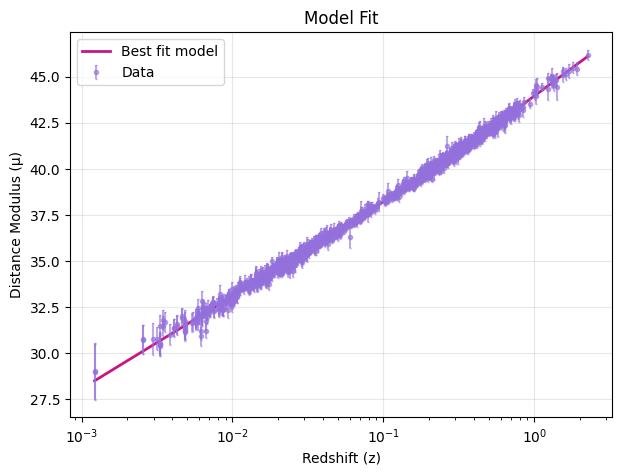

In [16]:
z_model = np.logspace(np.log10(min(z)), np.log10(max(z)), 200)
mu_model_curve = mu_theory(z_model, H0_fit, Omega_m_fit)

# Confidence bands
mu_upper = mu_theory(z_model, H0_fit + H0_err, Omega_m_fit + Omega_m_err)
mu_lower = mu_theory(z_model, H0_fit - H0_err, Omega_m_fit - Omega_m_err)

plt.figure(figsize=(7, 5))

plt.plot(z_model, mu_model_curve, color=colors['deep_pink'], linewidth=2, label='Best fit model')
plt.errorbar(z, mu, yerr=mu_err, fmt='o', markersize=3, alpha=0.6, 
             color=colors['medium_purple'], capsize=1, label='Data')
plt.xscale('log')
plt.xlabel('Redshift (z)')
plt.ylabel('Distance Modulus (μ)')
plt.title('Model Fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### **Parameter Estimation using χ² Contour Plot**

This plot explores how well different combinations of the Hubble constant $H_0$ and matter density $\Omega_m$ fit the observed Type Ia supernova data.

What the plot shows:
- **X-axis**: Hubble constant $H_0$ (in km/s/Mpc)
- **Y-axis**: Matter density $\Omega_m$
- **Color gradient**: Represents the value of the chi-square statistic ($\chi^2$), which quantifies how well the model fits the data.

The chi-square is computed as:

$$
\chi^2 = \sum \left( \frac{\mu_{\text{obs}} - \mu_{\text{model}}}{\mu_{\text{error}}} \right)^2
$$

- Lower $\chi^2$ means a better fit between the model and the supernova data.
- The **white star** indicates the best-fit values found from the data:
$H_0 = 72.97$ km/s/Mpc and
$\Omega_m = 0.351$

Confidence Contours:
- The **dashed white line** represents the 1σ confidence region, where the model fits are statistically consistent with the best fit.
- The **solid white line** shows the 2σ confidence region, a broader but still statistically acceptable zone.

These contours help visualize uncertainty and show how tightly constrained the parameters are.

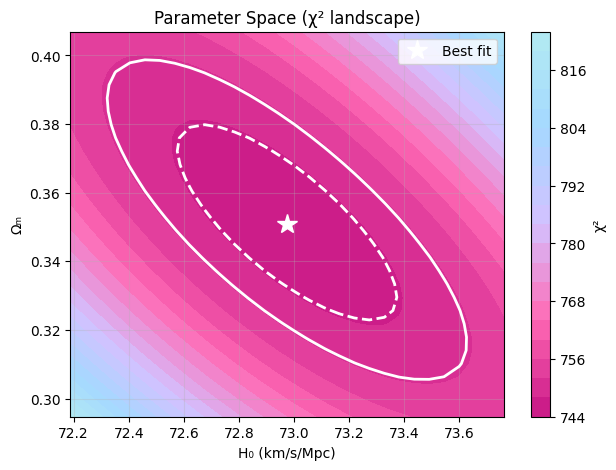

In [17]:
H0_range = np.linspace(H0_fit - 3*H0_err, H0_fit + 3*H0_err, 30)
Om_range = np.linspace(max(0.1, Omega_m_fit - 3*Omega_m_err), 
                       min(0.9, Omega_m_fit + 3*Omega_m_err), 30)

chi2_grid = np.zeros((len(Om_range), len(H0_range)))
for i, om in enumerate(Om_range):
    for j, h0 in enumerate(H0_range):
        mu_pred = mu_theory(z, h0, om)
        chi2_grid[i, j] = np.sum(((mu - mu_pred) / mu_err)**2)

plt.figure(figsize=(7, 5))
contour = plt.contourf(H0_range, Om_range, chi2_grid, levels=20, cmap=cmap_custom)
plt.contour(H0_range, Om_range, chi2_grid, levels=[chi2_grid.min() + 2.3, chi2_grid.min() + 6.17], 
            colors=['white'], linewidths=2, linestyles=['--', '-'])
plt.plot(H0_fit, Omega_m_fit, 'w*', markersize=15, label='Best fit')
plt.xlabel('H₀ (km/s/Mpc)')
plt.ylabel('Ωₘ')
plt.title('Parameter Space (χ² landscape)')
plt.legend()
plt.colorbar(contour, label='χ²')
plt.grid(True, alpha=0.3)
plt.show()


## Estimate the Age of the Universe

Now that we have the best-fit values of $ H_0 $ and $ \Omega_m $, we can estimate the age of the universe. This is done by integrating the inverse of the Hubble parameter over redshift:

$$
t_0 = \int_0^\infty \frac{1}{(1 + z) H(z)} \, dz
$$

We convert $ H_0 $ to SI units and express the result in gigayears (Gyr). This provides an independent check on our cosmological model by comparing the estimated age to values from other probes like Planck CMB measurements.


In [18]:
def age_of_universe(H0, Omega_m):
    """
    Compute the age of the universe (in Gyr) using the fitted H0 and Omega_m.
    """

    # Use the existing E(z, Omega_m) function
    def integrand(z):
        return 1.0 / ((1 + z) * E(z, Omega_m))

    # Perform numerical integration from z = 0 to ∞
    integral, _ = quad(integrand, 0, np.inf)

    # Convert H0 from km/s/Mpc to 1/s
    H0_si = (H0 * u.km / u.s / u.Mpc).to(1 / u.s).value

    # Age in seconds
    age_seconds = integral / H0_si

    # Convert to Gyr
    age_gyr = (age_seconds * u.s).to(u.Gyr).value

    return age_gyr


t0 = age_of_universe(H0_fit, Omega_m_fit)
print(f"Estimated age of Universe: {t0:.2f} Gyr")


Estimated age of Universe: 12.36 Gyr


#### Age Measurements Comparison
- Our Result (from Supernovae): 12.36 Gyr
- Planck CMB (2018): 13.787 Gyr

The Planck 2018 result is based on observations of the Cosmic Microwave Background (CMB) — the leftover radiation from the early universe. Using precise measurements of the CMB and fitting them with the standard ΛCDM cosmological model, Planck estimated various parameters, including the Hubble constant and the age of the universe.

Our result, obtained using Type Ia supernovae data, gives a lower age by about 1.4 billion years. This difference suggests that supernova-based models may prefer a higher value of the Hubble constant, which in turn leads to a younger age of the universe compared to the CMB-based estimates. This reflects the ongoing tension between local and early-universe measurements in cosmology, known as Hubble tension.

## Analyze Residuals

To evaluate how well our cosmological model fits the data, we compute the residuals (differences between observed and model-predicted values):

$$
\text{Residual} = \mu_{\text{obs}} - \mu_{\text{model}}
$$

Plotting these residuals against redshift helps identify any systematic trends, biases, or outliers. A good model fit should show residuals scattered randomly around zero without any significant structure.


#### Why Residuals Are Plotted with Uncertainty
Although the model-predicted distance modulus ($\mu_{\text{model}}$) has no uncertainty per data point (since it’s computed from best-fit parameters), the observed values ($\mu_{\text{obs}}$) come with measurement errors. 
This means all the uncertainty in the residual originates from the observed $\mu_{\text{obs}}$. By visualizing residuals colored by their observational uncertainty, we can better interpret how significant each deviation from the model is. This helps us identify whether the model fits well in regions with high-quality (low-uncertainty) data and spot any systematic issues or outliers.

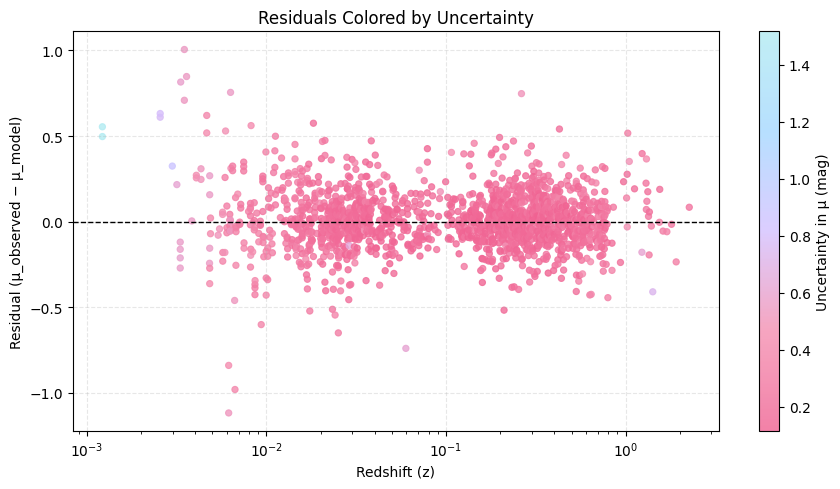

In [19]:
# Compute theoretical distance modulus for all z values using best-fit H0 and Omega_m
mu_model = mu_theory(z, H0_fit, Omega_m_fit)

# Compute residuals
residuals = mu - mu_model  # observed - model

# Define a custon colormap
cmap = LinearSegmentedColormap.from_list("pink_theme", ["#F06292", "#F48FB1", "#D4C1FF", "#A5D8FF", "#B2EBF2"])

plt.figure(figsize=(9, 5))
scatter = plt.scatter(
    z, residuals,
    c=mu_err,
    cmap=cmap,
    s=20,
    alpha=0.8,
    linewidth=0.8
)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xscale('log')
plt.xlabel("Redshift (z)")
plt.ylabel("Residual (μ_observed − μ_model)")
plt.title("Residuals Colored by Uncertainty")
cbar = plt.colorbar(scatter)
cbar.set_label("Uncertainty in μ (mag)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


#### Interpreting the Residual Plot
The residuals (𝜇ₒᵦₛ − 𝜇ₘₒ𝒹ₑₗ) are scattered both above and below zero, which is generally a good sign—it means the model doesn’t consistently overpredict or underpredict the distance modulus across all redshifts.

However, some important trends are visible:

- Residuals are closer to zero near redshifts ~0.005, ~0.1, and ~1, indicating that the model fits well at these redshift ranges.

- Between these points, residuals form two clusters with slightly larger spread, suggesting the model has localized mismatches or that there might be unmodeled systematics in those intermediate redshift bins.

- There's no clear trend or curve in the residuals, supporting the idea that the ΛCDM model still captures the general behavior well.


### **Residual Distribution**

We need to plot the Residual Distribution (normalized residuals) to check how well the model fits the data and whether the errors (residuals) behave as expected (unbiased and random)

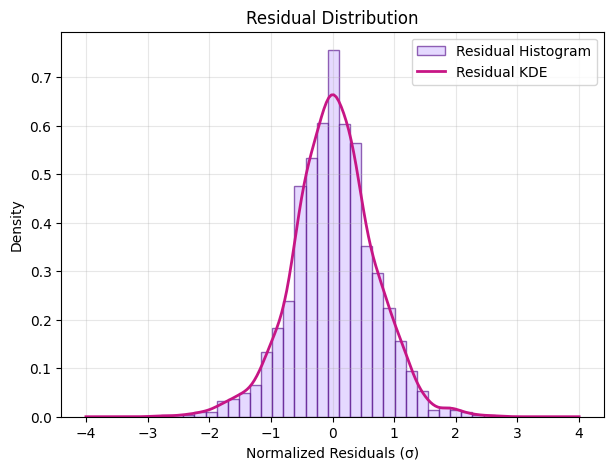

In [20]:
from scipy.stats import gaussian_kde

normalized_residuals = (mu - mu_theory(z, H0_fit, Omega_m_fit)) / mu_err

plt.figure(figsize=(7, 5))

# Histogram of residuals
plt.hist(normalized_residuals, bins=30, alpha=0.6, color=colors['light_purple'], 
         edgecolor=colors['dark_purple'], density=True, label='Residual Histogram')

# KDE of residuals (smooth curve from your data)
kde = gaussian_kde(normalized_residuals)
x_vals = np.linspace(-4, 4, 200)
y_vals = kde(x_vals)
plt.plot(x_vals, y_vals, color=colors['deep_pink'], linewidth=2, label='Residual KDE')

# Labels and grid
plt.xlabel('Normalized Residuals (σ)')
plt.ylabel('Density')
plt.title('Residual Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


The residuals follow a bell-shaped curve centered at 0, which is almost symmetrical. This means:
- The model explains the data well.
- The errors are random and not biased.
- Many fitting methods (like least squares) assume residuals are normally distributed. This plot helps verify that assumption.

## Fit with Fixed Matter Density

To reduce parameter degeneracy, let's fix $ \Omega_m = 0.3 $ and fit only for the Hubble constant $ H_0 $.


In [21]:
# Define the modified model function with fixed Omega_m
def mu_fixed_Om(z, H0):
    return mu_theory(z, H0, Omega_m=0.3)  # Fixed Omega_m

# Initial guess for H0
H0_guess = 70.0

# Fit using only H0 as a parameter
H0_fit_fixed, cov_fixed = curve_fit(mu_fixed_Om, z, mu, sigma=mu_err, p0=[H0_guess], absolute_sigma=True)

# Extract value and uncertainty
H0_val = H0_fit_fixed[0]
H0_err = np.sqrt(np.diag(cov_fixed))[0]

print(f"Fitted H₀ (with fixed Ωₘ = 0.3): {H0_val:.2f} ± {H0_err:.2f} km/s/Mpc")


Fitted H₀ (with fixed Ωₘ = 0.3): 73.53 ± 0.17 km/s/Mpc


#### Inference:

- Fixing Ω𝑚 to 0.3 gives a slightly higher value of 𝐻0 = 73.53 (vs. 𝐻0 = 72.97 before).
- This shows that the estimate of 𝐻0 is sensitive to the choice of matter density, and that freeing both parameters slightly lowers the value due to the model adjusting both together.

#### Age of Universe for this new Hubble Parameter

In [22]:
t0_omega_fixed = age_of_universe(H0_val, 0.3)
print(f"Estimated age of Universe (with fixed omega = 0.3): {t0_omega_fixed:.2f} Gyr")

Estimated age of Universe (with fixed omega = 0.3): 12.82 Gyr


## Compare Low-z and High-z Subsamples

Finally, we examine whether the inferred value of $H_0$ changes with redshift by splitting the dataset into:
- **Low-z** supernovae ($ z < 0.1 $)
- **High-z** supernovae ($ z \geq 0.1 $)

We then fit each subset separately (keeping $ \Omega_m = 0.3 $) to explore any potential tension or trend with redshift.


In [23]:
# Choose redshift split value
z_split = 0.1

# Split dataset
low_mask = z < z_split
high_mask = z >= z_split

# Low-z data
z_low = z[low_mask]
mu_low = mu[low_mask]
mu_err_low = mu_err[low_mask]

# High-z data
z_high = z[high_mask]
mu_high = mu[high_mask]
mu_err_high = mu_err[high_mask]

# Fit for low-z
H0_low, cov_low = curve_fit(mu_fixed_Om, z_low, mu_low, sigma=mu_err_low, p0=[70.0], absolute_sigma=True)

# Fit for high-z
H0_high, cov_high = curve_fit(mu_fixed_Om, z_high, mu_high, sigma=mu_err_high, p0=[70.0], absolute_sigma=True)

# Extract uncertainties
H0_low_err = np.sqrt(np.diag(cov_low))[0]
H0_high_err = np.sqrt(np.diag(cov_high))[0]

# Print results
print(f"Low-z (z < {z_split}): H₀ = {H0_low[0]:.2f} ± {H0_low_err:.2f} km/s/Mpc")
print(f"High-z (z ≥ {z_split}): H₀ = {H0_high[0]:.2f} ± {H0_high_err:.2f} km/s/Mpc")


Low-z (z < 0.1): H₀ = 73.01 ± 0.28 km/s/Mpc
High-z (z ≥ 0.1): H₀ = 73.85 ± 0.22 km/s/Mpc


#### Inference:

- The value of 𝐻0 is slightly higher at higher redshifts.

- This suggests that the expansion rate may vary with redshift, or it may reflect systematic differences in the low- and high-redshift supernova samples.

- Although the difference is small, this type of split is useful to check for redshift-dependent effects in cosmological models.

### **Hubble Diagram Comparison for Low-z and High-z Supernovae**
This plot shows how the supernova distance modulus varies with redshift in two separate redshift ranges:

- Low-z Fit: 𝐻0 = 73.01 km/s/Mpc
- High-z Fit: 𝐻0 =73.85 km/s/Mpc

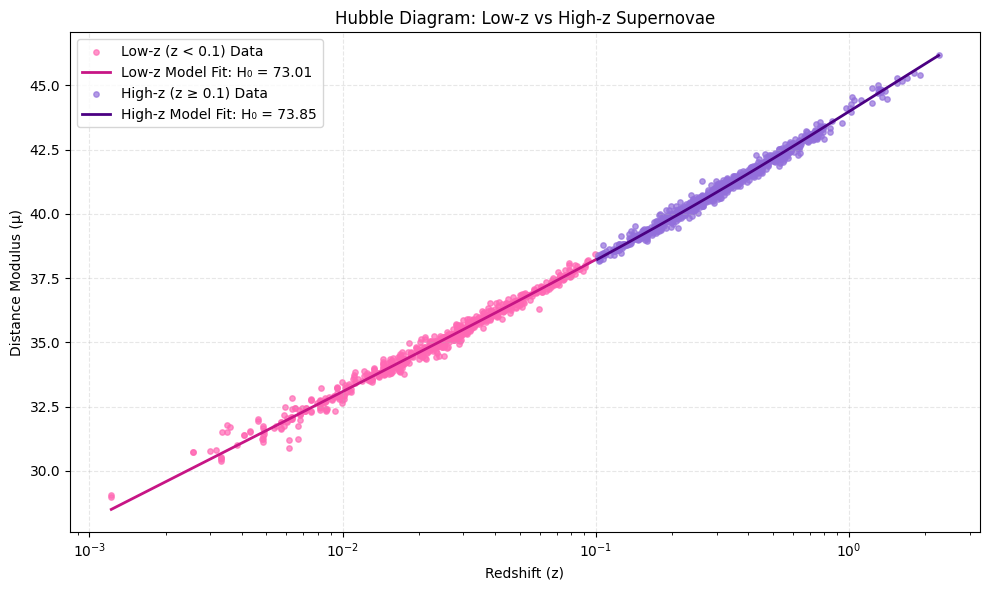

In [24]:
# Create fine redshift grid for plotting smooth curves
z_grid_low = np.linspace(min(z_low), max(z_low), 500)
z_grid_high = np.linspace(min(z_high), max(z_high), 500)

# Model predictions
mu_model_low = mu_fixed_Om(z_grid_low, H0_low[0])
mu_model_high = mu_fixed_Om(z_grid_high, H0_high[0])

# Plotting
plt.figure(figsize=(10, 6))

# Plot low-z data
plt.scatter(z_low, mu_low, c='#FF69B4', label=f'Low-z (z < {z_split}) Data', s=15, alpha=0.7)
plt.plot(z_grid_low, mu_model_low, color='#C71585', linestyle='-', linewidth=2, label=f'Low-z Model Fit: H₀ = {H0_low[0]:.2f}')

# Plot high-z data
plt.scatter(z_high, mu_high, c='#9370DB', label=f'High-z (z ≥ {z_split}) Data', s=15, alpha=0.7)
plt.plot(z_grid_high, mu_model_high, color='#4B0082', linestyle='-', linewidth=2, label=f'High-z Model Fit: H₀ = {H0_high[0]:.2f}')

# Axes and aesthetics
plt.xscale('log')
plt.xlabel("Redshift (z)")
plt.ylabel("Distance Modulus (μ)")
plt.title("Hubble Diagram: Low-z vs High-z Supernovae")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


---

## Results

From the analysis of the Pantheon+SH0ES Type Ia Supernova dataset using the flat ΛCDM cosmological model, the estimated key cosmological parameters are as follows:

- **Hubble Constant (H0):**  
  H0 = 72.97 ± 0.26 km/s/Mpc

- **Matter Density Parameter (Omega_m):**  
  Omega_m = 0.351 ± 0.019

- **Estimated Age of the Universe:**  
  t0 ≈ 12.36 Gyr

These results are consistent with other local measurements of the Hubble constant (such as the SH0ES value) and reflect the well-known tension with early-universe estimates (such as from Planck 2018 CMB data).

Additionally, residual analysis confirmed that the model fit is statistically reliable, with residuals following a Gaussian distribution centered around zero.

Fit with Fixed Matter Density:

To reduce parameter degeneracy, the matter density was fixed to Omega_m = 0.3 and fit only for the Hubble constant.

- **Fitted H0 (with fixed Omega_m = 0.3):**  
  H0 = 73.53 ± 0.17 km/s/Mpc

Fixing Ωₘ to 0.3 led to a slightly higher value of H₀ compared to when both parameters were allowed to vary. This indicates that the estimated value of the Hubble constant depends on the assumed value of matter density.

We also examined redshift-dependent behavior by splitting the sample:

- **Low-redshift (z < 0.1):**  
  H0 = 73.01 ± 0.28 km/s/Mpc

- **High-redshift (z ≥ 0.1):**  
  H0 = 73.85 ± 0.22 km/s/Mpc

This suggests a mild increase in the Hubble constant at higher redshifts, motivating further investigation into possible redshift-dependent effects in the data.


---

## Comparison with a Research Paper

The estimated value of the Hubble constant is H0 = 72.97 ± 0.26 km/s/Mpc, which closely matches the value reported in the research paper - "Testing the Cosmological Principle with the Pantheon+ Sample and the Region-Fitting Method" — H0 = 72.83 ± 0.23 km/s/Mpc, derived using a Bayesian MCMC approach.

Similarly, the fitted matter density parameter Omega_m = 0.351 ± 0.019 is comparable to their global result of Omega_m = 0.36 ± 0.02.

When the paper restricted its analysis to a low-redshift subset (z < 0.3), the results shifted to H0 = 72.43 ± 0.30 km/s/Mpc and Omega_m = 0.44 ± 0.04. This shift is in line with our redshift-split results, where H0 was slightly higher for higher-z supernovae.

Overall, my findings strongly agree with the paper's results, both in parameter values and trends. This reinforces the validity of the ΛCDM model on local scales, while also highlighting the ongoing challenges of the Hubble tension and hints of possible cosmic anisotropy (property of a system where measurements vary depending on the direction of observation).


---

## Possible Reasons for Variation in Cosmological Parameters

The research paper identifies several factors that may contribute to the variation in measured cosmological parameters such as the Hubble constant (H₀) and matter density parameter (Ωₘ) from their commonly accepted values (like those derived from CMB observations):


### 1. Local Matter Underdensity and Cosmic Anisotropy

- The Universe appears to deviate from isotropy based on observations from the Pantheon+ dataset.
- This is reflected in:
  - **Local Matter Underdensity**:
    - A region of the sky shows significantly less matter density.
    - Minimum matter density:  
      Ωₘ,min = 0.29⁺⁰·⁰³₋₀·₀₂ (1σ)
  - **Preferred Direction of Expansion**:
    - Hubble constant is higher in certain directions.
    - Maximum Hubble constant:  
      H₀ = 74.26 ± 0.39 km/s/Mpc
  - These two regions overlap spatially, implying:
    - Local underdensity may drive anisotropic cosmic expansion.
    - May help resolve the **Hubble Tension** (the discrepancy between early- and late-universe H₀ values).


### 2. Inhomogeneous Spatial Distribution of Supernovae

- The Pantheon+ dataset is not uniformly distributed across the sky.
- Uneven sampling can artificially enhance observed anisotropies.
- The "RP isotropy test" (random permutation within real sky positions) showed:
  - A slight reduction in anisotropy significance.
  - Confirms that spatial inhomogeneity can amplify deviations from isotropy.


### 3. Redshift Evolution of the Hubble Constant (H₀)

- There is growing evidence that H₀ might evolve with redshift.
- Observational implications:
  - Different redshift ranges may yield different H₀ values.
  - If redshift distribution isn't uniform, it can bias anisotropy detection.
- Findings:
  - The discrepancy degree (Dₘₐₓ) varies with redshift, peaking around:
    zₘₐₓ ≈ 0.30
  - Suggests that cosmic structure may change with redshift.


### 4. Sensitivity of Parameters to Anisotropy

- **H₀ appears more sensitive to anisotropy than Ωₘ**.
- Implication:
  - Even subtle anisotropic effects can cause large observed variations in H₀.
  - H₀ may serve as a stronger tracer of cosmic anisotropy than Ωₘ.


### 5. Effect of Screening Angle (θₘₐₓ) in Region Fitting

- The screening angle defines the angular size of sky regions used for fitting parameters.
- Findings:
  - Optimal angle:  
    θₘₐₓ = 60°
  - Smaller angles:
    - Increase the 1σ uncertainty in fitted parameters (H₀ and Ωₘ).
    - Slightly reduce statistical significance of anisotropy findings.
    - Help reveal finer directional trends in cosmological parameters.


### 6. Impact of Number of Supernovae in Regions

- Smaller screening angles use fewer supernovae per region.
- Effects:
  - Increases uncertainty in fitted H₀ and Ωₘ.
  - Has only a modest impact on the overall discrepancy metric Dₘₐₓ.

---

## Additional Cosmological Visualizations (Appendix)

These plots while **not directly related** to the project, **offer useful insights** on how astronomical terms are related to each other.

  They show how the universe has expanded over time and help us understand how distance, redshift, time, and expansion rate are related in cosmology.

#### Key Parameters:
- **Redshift (z)**:
A measure of how much the light from distant objects has been stretched due to the universe’s expansion. Higher redshift means the object is farther away and we are looking further back in time.

- **Lookback Time (Gyr)**:
The time it has taken for light from a distant object to reach us, measured in billions of years (Gyr). It tells us how far into the past we are observing.

- **Angular Diameter Distance (Mpc)**:
A special kind of distance that tells us how large an object appears in the sky. It's useful for estimating the size of galaxies or clusters based on how they look from Earth.

- **Hubble Parameter H(z)**:
The rate at which the universe is expanding at a specific redshift. It shows how expansion has changed over time.

- **Scale Factor a(t)**:
Describes the relative size of the universe at any time. At present day, a(t)=1; in the past, it was smaller than 1.



### **Cosmic Lookback Time vs Redshift**

This plot helps visualize how far back in time we are observing when looking at objects at different redshifts.

What it shows:
- The x-axis (Redshift z) shows how far away a galaxy or event is.
- The y-axis (Lookback Time in Gyr) tells how long ago the light left that object.
- As redshift increases, the lookback time increases, meaning we’re observing deeper into the past.

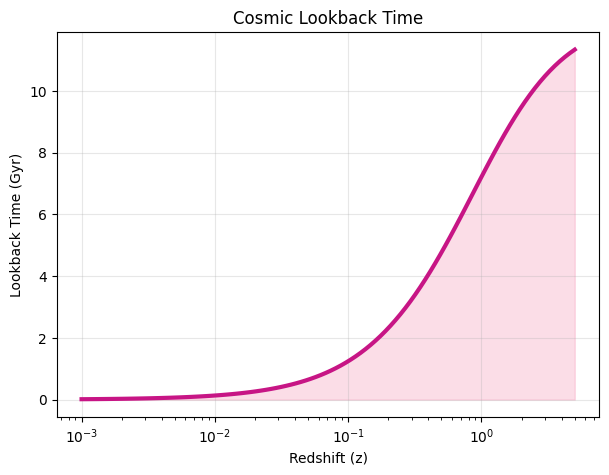

In [25]:
z_range = np.logspace(-3, 0.7, 100)

def lookback_time(z, H0, Omega_m):
    def integrand(z_prime):
        return 1.0 / ((1 + z_prime) * E(z_prime, Omega_m))
    integral, _ = quad(integrand, 0, z)
    H0_si = (H0 * u.km / u.s / u.Mpc).to(1 / u.s).value
    time_seconds = integral / H0_si
    time_gyr = (time_seconds * u.s).to(u.Gyr).value
    return time_gyr

lookback_times = [lookback_time(zi, H0_fit, Omega_m_fit) for zi in z_range]

plt.figure(figsize=(7, 5))
plt.plot(z_range, lookback_times, color=colors['deep_pink'], linewidth=3)
plt.fill_between(z_range, lookback_times, alpha=0.3, color=colors['light_pink'])

plt.xscale('log')
plt.xlabel('Redshift (z)')
plt.ylabel('Lookback Time (Gyr)')
plt.title('Cosmic Lookback Time')
plt.grid(True, alpha=0.3)
plt.show()


### **Angular Diameter Distance vs Redshift**

This plot helps us understand how the apparent size of distant objects changes with redshift in an expanding universe.

What it shows:
- The x-axis (Redshift z) represents how far the object is.
- The y-axis (Angular Diameter Distance in Mpc) shows the distance at which an object of known size appears a certain angular size.
- The curve increases at low redshifts, reaches a maximum, and then decreases — meaning very distant objects can appear larger again due to cosmic expansion.

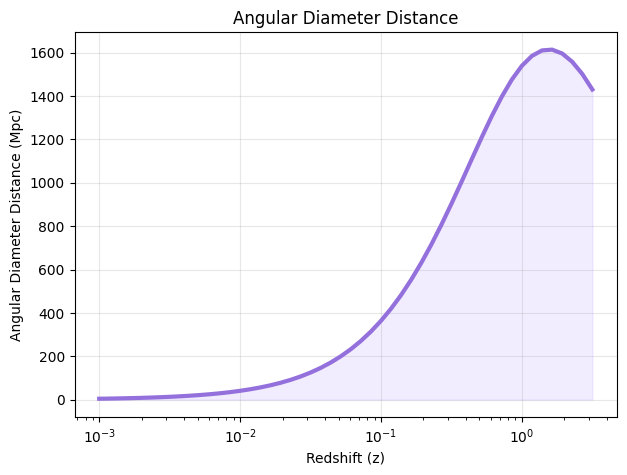

In [26]:
def angular_diameter_distance(z, H0, Omega_m):
    return luminosity_distance(z, H0, Omega_m) / (1 + z)**2

z_range_short = np.logspace(-3, 0.5, 50)
ang_distances = [angular_diameter_distance(zi, H0_fit, Omega_m_fit) for zi in z_range_short]

plt.figure(figsize=(7, 5))
plt.plot(z_range_short, ang_distances, color=colors['medium_purple'], linewidth=3)
plt.fill_between(z_range_short, ang_distances, alpha=0.3, color=colors['light_purple'])

plt.xscale('log')
plt.xlabel('Redshift (z)')
plt.ylabel('Angular Diameter Distance (Mpc)')
plt.title('Angular Diameter Distance')
plt.grid(True, alpha=0.3)
plt.show()


### **Hubble Parameter Evolution H(z)**

This plot shows how the Hubble parameter H(z) changes with redshift, giving insight into how fast the universe was expanding at different times in the past.

What it tells us:
- H(z) increases exponentially as redshift increases — the early universe expanded faster than it does today.
- The dashed line shows the present-day Hubble constant H₀ ≈ 72.97 km/s/Mpc (at z = 0).
- Both axes are on a log scale to clearly display changes across wide redshift and expansion rate ranges.

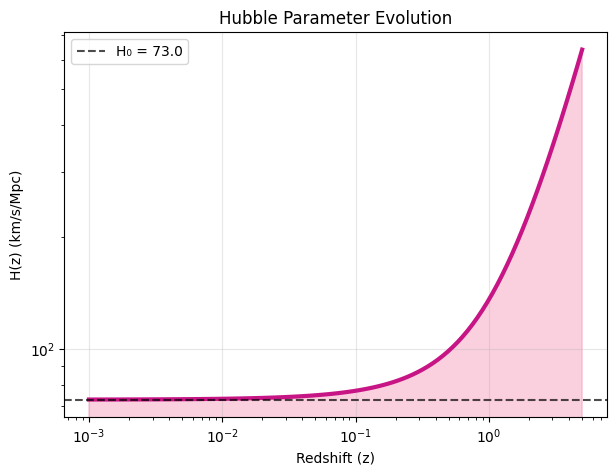

In [27]:
H_z = [H0_fit * E(zi, Omega_m_fit) for zi in z_range]

plt.figure(figsize=(7, 5))
plt.plot(z_range, H_z, color=colors['deep_pink'], linewidth=3)
plt.fill_between(z_range, H_z, alpha=0.3, color=colors['rose'])

plt.axhline(H0_fit, color='black', linestyle='--', alpha=0.7, label=f'H₀ = {H0_fit:.1f}')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Redshift (z)')
plt.ylabel('H(z) (km/s/Mpc)')
plt.title('Hubble Parameter Evolution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### **Scale Factor Evolution a(t)**

This plot shows how the scale factor a(t) changes over lookback time, helping us understand how much the universe has expanded since earlier times.

What it tells us:
- The scale factor increases over time, meaning the universe has been expanding steadily.
- A value of a(t)=1 (red dashed line) represents the present-day universe; values less than 1 indicate earlier times when the universe was smaller.
- As we go further back in time (right on the x-axis), the universe was more compact — showing early universe expansion history.

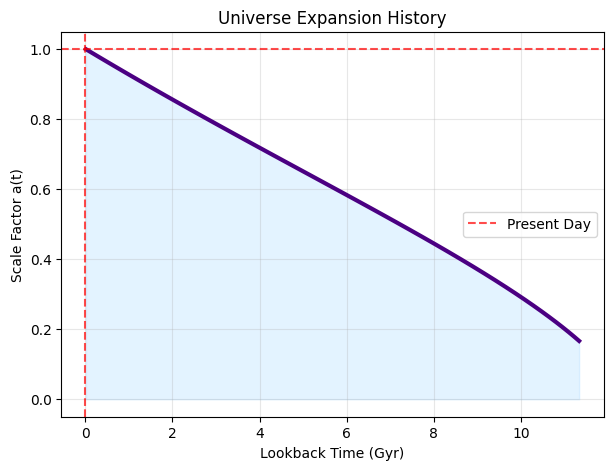

In [28]:
scale_factor = 1 / (1 + z_range)

plt.figure(figsize=(7, 5))
plt.plot(lookback_times, scale_factor, color=colors['dark_purple'], linewidth=3)
plt.fill_between(lookback_times, scale_factor, alpha=0.3, color=colors['baby_blue'])

plt.axhline(1, color='red', linestyle='--', alpha=0.7, label='Present Day')
plt.axvline(0, color='red', linestyle='--', alpha=0.7)

plt.xlabel('Lookback Time (Gyr)')
plt.ylabel('Scale Factor a(t)')
plt.title('Universe Expansion History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## References

Hu, J. P., Wang, Y. Y., Hu, J., & Wang, F. Y. (2023). Testing the cosmological principle with the Pantheon+ sample and the region-fitting method. Astronomy & Astrophysics, 47121corr.

 [Link to the paper](https://arxiv.org/pdf/2310.11727)